In [63]:
import pandas as pd
import numpy as np
from matplotlib import pyplot  as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [64]:
bureau=pd.read_csv('bureau_data.csv')
customers=pd.read_csv('customers.csv')
loans=pd.read_csv('loans.csv')

In [65]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [66]:
bureau

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10
...,...,...,...,...,...,...,...,...
49995,C49996,4,2,165,1,6,8,24
49996,C49997,4,0,161,0,0,4,91
49997,C49998,4,1,42,0,0,7,38
49998,C49999,1,2,42,9,47,4,17


In [67]:
customers.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [68]:
loans.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [69]:
bureau.shape

(50000, 8)

In [70]:
customers.shape

(50000, 12)

In [71]:
loans.shape

(50000, 15)

In [72]:
bureau.describe()

,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,2.50,1.00,76.13,4.88,26.86,5.01,43.36
std,1.12,0.81,43.76,5.85,32.83,2.03,29.36
min,1.00,0.00,1.00,0.00,0.00,1.00,0.00
25%,1.00,0.00,42.00,0.00,0.00,4.00,18.00
50%,3.00,1.00,71.00,3.00,14.00,5.00,39.00
75%,4.00,2.00,107.00,9.00,46.00,6.00,67.00
max,4.00,2.00,223.00,24.00,171.00,9.00,99.00


In [73]:
customers.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode
count,50000.00,50000.00,50000.00,50000.00,50000.00
mean,39.55,2640897.50,1.94,16.02,419090.86
std,9.85,2629441.06,1.54,8.93,168982.67
min,18.00,0.00,0.00,1.00,110001.00
25%,33.00,803000.00,0.00,8.00,302001.00
50%,40.00,1892000.00,2.00,16.00,400001.00
75%,46.00,3332250.00,3.00,24.00,560001.00
max,70.00,11999000.00,5.00,31.00,700001.00


In [74]:
loans.describe()

,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,4704827.52,3999678.80,80494.71,719942.18,3199743.04,25.94,1337636.04,989126.38
std,6267276.39,5376552.03,117312.26,967779.37,4301241.63,12.43,1214713.89,1046071.89
min,0.00,0.00,0.00,0.00,0.00,6.00,-1.00,0.00
25%,1147000.00,967000.00,19340.00,174060.00,773600.00,16.00,424799.00,287007.50
50%,2656000.00,2240000.00,44800.00,403200.00,1792000.00,24.00,1002309.00,668525.00
75%,5172250.00,4611000.00,92240.00,829980.00,3688800.00,35.00,1790751.00,1238667.00
max,52175000.00,47819000.00,5698029.90,8607420.00,38255200.00,59.00,5000000.00,7846643.00


In [75]:
bureau.isnull().sum()

cust_id                      0
number_of_open_accounts      0
number_of_closed_accounts    0
total_loan_months            0
delinquent_months            0
total_dpd                    0
enquiry_count                0
credit_utilization_ratio     0
dtype: int64

In [76]:
customers.isnull().sum()

cust_id                      0
age                          0
gender                       0
marital_status               0
employment_status            0
income                       0
number_of_dependants         0
residence_type              62
years_at_current_address     0
city                         0
state                        0
zipcode                      0
dtype: int64

### customers-> residence type contains some null value

In [77]:
loans.isnull().sum()

loan_id                        0
cust_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
default                        0
dtype: int64

In [78]:
bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   cust_id                    50000 non-null  object
 1   number_of_open_accounts    50000 non-null  int64 
 2   number_of_closed_accounts  50000 non-null  int64 
 3   total_loan_months          50000 non-null  int64 
 4   delinquent_months          50000 non-null  int64 
 5   total_dpd                  50000 non-null  int64 
 6   enquiry_count              50000 non-null  int64 
 7   credit_utilization_ratio   50000 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 3.1+ MB


In [79]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cust_id                   50000 non-null  object
 1   age                       50000 non-null  int64 
 2   gender                    50000 non-null  object
 3   marital_status            50000 non-null  object
 4   employment_status         50000 non-null  object
 5   income                    50000 non-null  int64 
 6   number_of_dependants      50000 non-null  int64 
 7   residence_type            49938 non-null  object
 8   years_at_current_address  50000 non-null  int64 
 9   city                      50000 non-null  object
 10  state                     50000 non-null  object
 11  zipcode                   50000 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 4.6+ MB


In [80]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loan_id                      50000 non-null  object 
 1   cust_id                      50000 non-null  object 
 2   loan_purpose                 50000 non-null  object 
 3   loan_type                    50000 non-null  object 
 4   sanction_amount              50000 non-null  int64  
 5   loan_amount                  50000 non-null  int64  
 6   processing_fee               50000 non-null  float64
 7   gst                          50000 non-null  int64  
 8   net_disbursement             50000 non-null  int64  
 9   loan_tenure_months           50000 non-null  int64  
 10  principal_outstanding        50000 non-null  int64  
 11  bank_balance_at_application  50000 non-null  int64  
 12  disbursal_date               50000 non-null  object 
 13  installment_star

In [81]:
bureau_df = bureau.select_dtypes(include=['number']).columns.tolist()
bureau_df

['number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

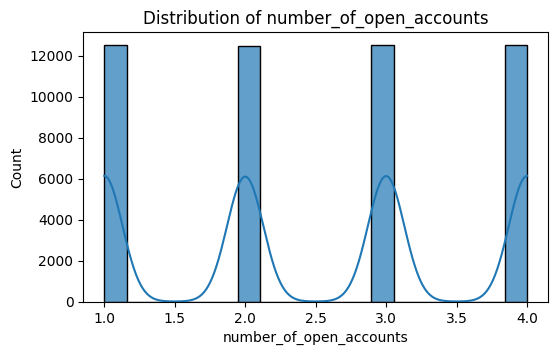

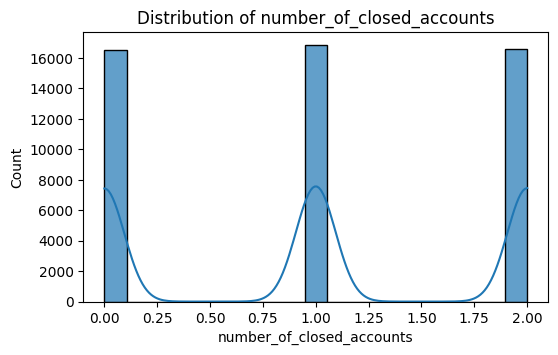

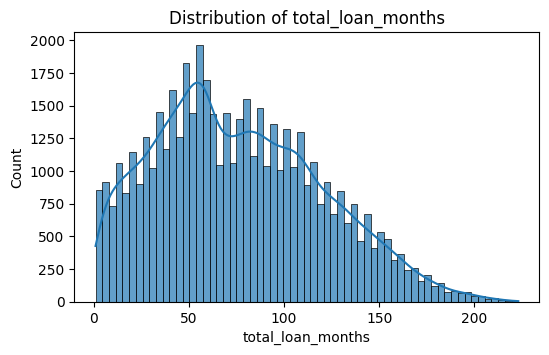

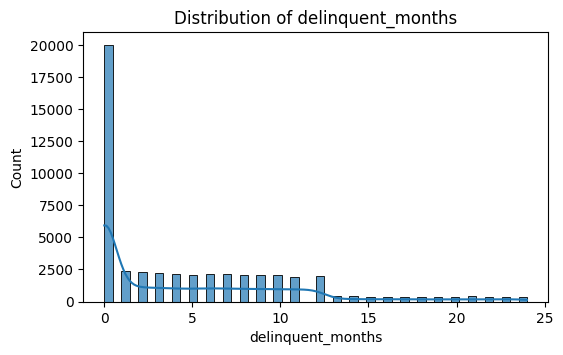

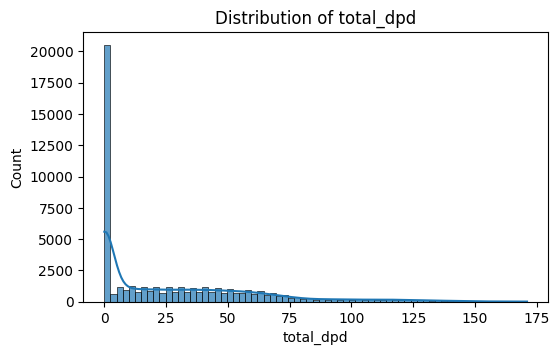

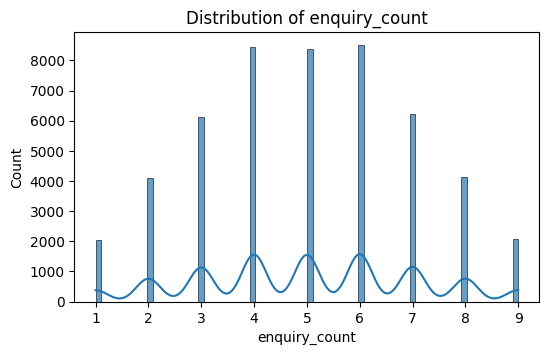

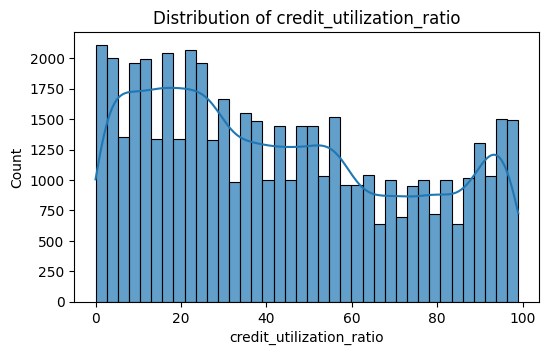

In [82]:
for cols in bureau_df:
    plt.figure(figsize=(6, 3.5))
    sns.histplot(bureau[cols], edgecolor='black', alpha=0.7,kde=True)
    plt.title(f'Distribution of {cols}')
    plt.xlabel(cols)
    plt.ylabel('Count')
    plt.show()

<Axes: xlabel='number_of_open_accounts', ylabel='count'>

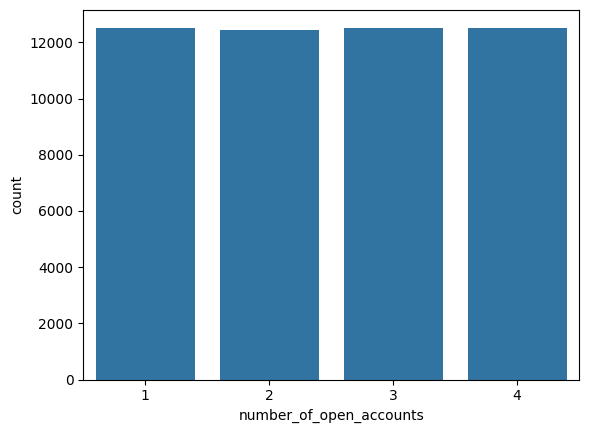

In [83]:
sns.countplot(x=bureau['number_of_open_accounts'])

### Findings outliers

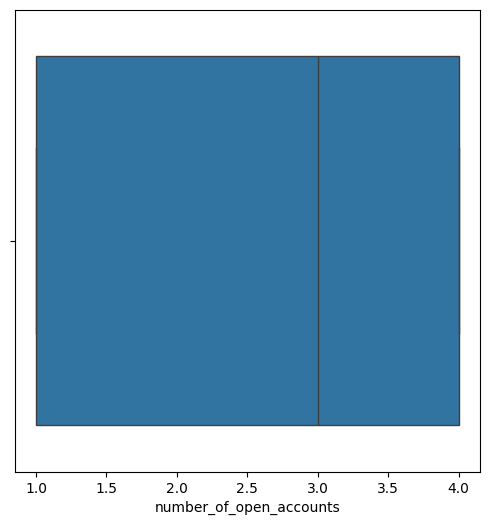

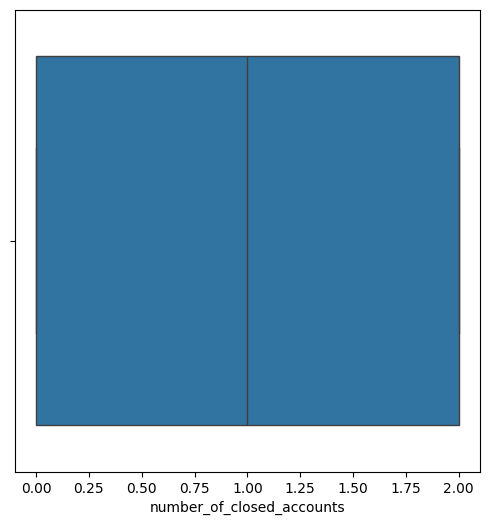

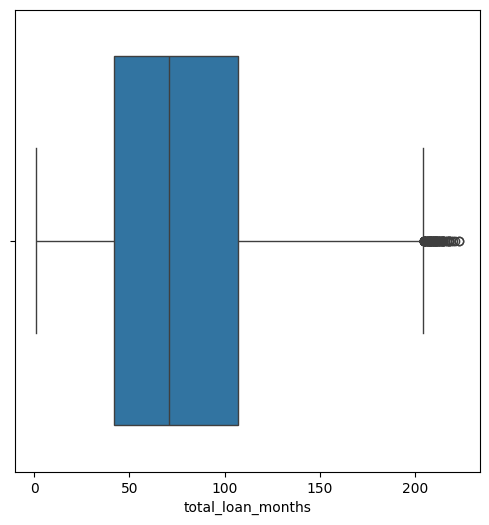

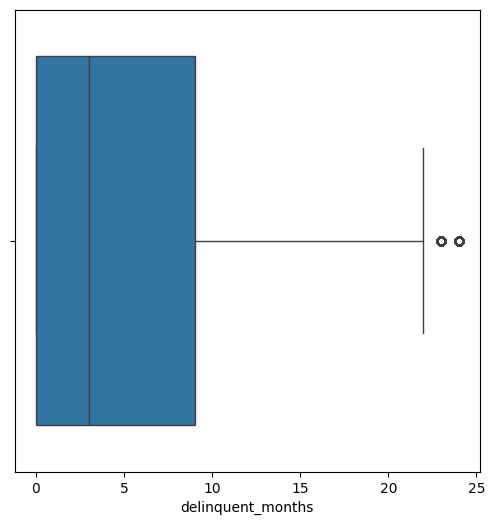

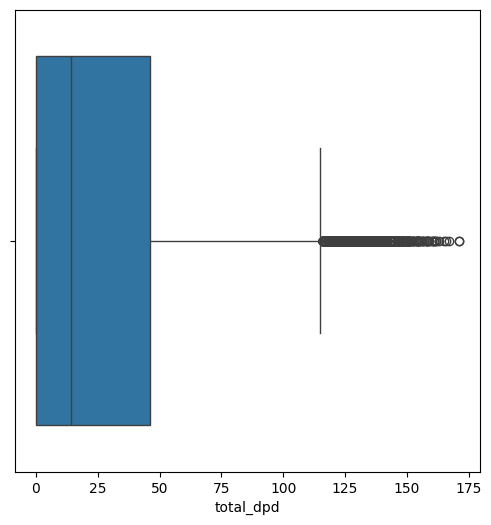

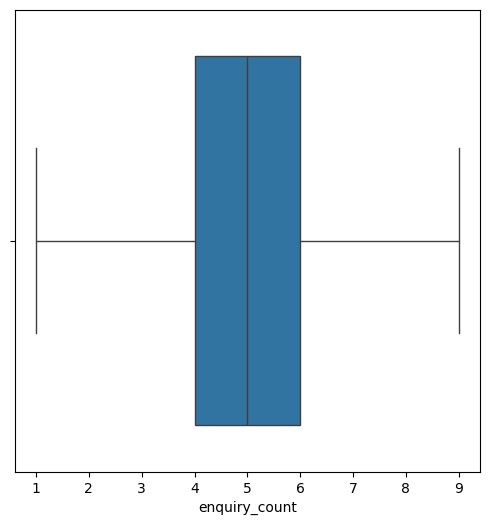

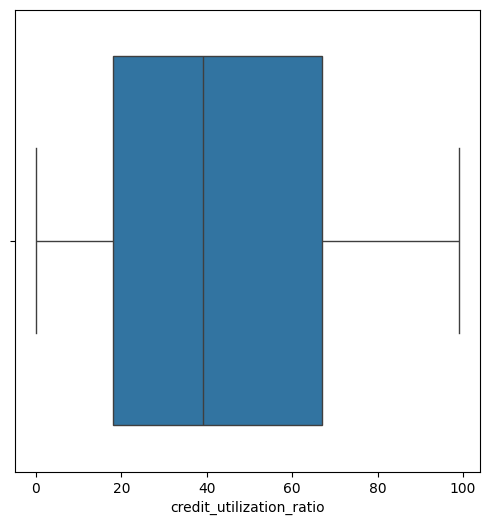

In [84]:
for cols in bureau_df:
    plt.figure(figsize=(6,6))
    sns.boxplot(x=bureau[cols])

### Total_loans_months and delinquent_monts contains outliers

### Finding Correlations

<Axes: >

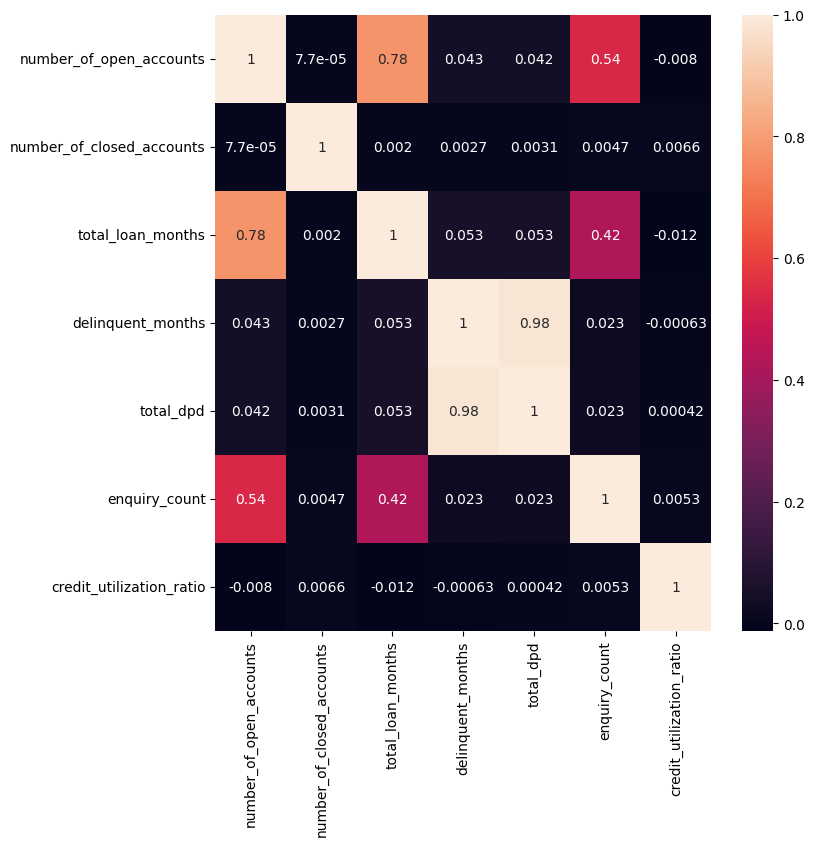

In [85]:
plt.figure(figsize=(8,8))
sns.heatmap(bureau.corr(numeric_only=True),annot=True)

### Data Cleaning

In [86]:
bureau_cleaned=bureau.copy()
bureau_cleaned.head()

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10


In [87]:
bureau_cleaned.duplicated().sum()

np.int64(0)

In [88]:
bureau_cleaned.isnull().sum()

cust_id                      0
number_of_open_accounts      0
number_of_closed_accounts    0
total_loan_months            0
delinquent_months            0
total_dpd                    0
enquiry_count                0
credit_utilization_ratio     0
dtype: int64

In [89]:
bureau_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   cust_id                    50000 non-null  object
 1   number_of_open_accounts    50000 non-null  int64 
 2   number_of_closed_accounts  50000 non-null  int64 
 3   total_loan_months          50000 non-null  int64 
 4   delinquent_months          50000 non-null  int64 
 5   total_dpd                  50000 non-null  int64 
 6   enquiry_count              50000 non-null  int64 
 7   credit_utilization_ratio   50000 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 3.1+ MB


### loans

In [90]:
loans.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [91]:
loans['default']=loans['default'].astype(int)
loans

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,0
1,L00002,C00002,Home,Secured,4161000,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,0
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,0
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,0
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,L49996,C49996,Personal,Unsecured,610000,535000,10700.00,96300,428000,22,385199,178470,2024-07-22,2024-08-15,0
49996,L49997,C49997,Auto,Secured,4211000,3243000,64860.00,583740,2594400,15,1656484,1040735,2024-07-22,2024-07-29,0
49997,L49998,C49998,Home,Secured,4097000,3740000,74800.00,673200,2992000,37,912691,355461,2024-07-22,2024-07-25,0
49998,L49999,C49999,Home,Secured,1871000,1630000,32600.00,293400,1304000,37,300035,179453,2024-07-22,2024-07-29,0


In [92]:
loans['default'].value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

## merging the dataframe 

In [93]:
df=pd.merge(bureau,customers,on='cust_id')
df

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,1,1,42,0,0,3,7,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,3,1,96,12,60,5,4,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,2,1,82,24,147,6,58,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,3,0,115,15,87,5,26,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,4,2,120,0,0,5,10,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,C49996,4,2,165,1,6,8,24,40,F,Single,Salaried,775000,2,Owned,11,Chennai,Tamil Nadu,600001
49996,C49997,4,0,161,0,0,4,91,39,M,Single,Salaried,3117000,0,Owned,9,Kolkata,West Bengal,700001
49997,C49998,4,1,42,0,0,7,38,45,F,Single,Self-Employed,1329000,0,Rented,27,Bangalore,Karnataka,560001
49998,C49999,1,2,42,9,47,4,17,42,F,Single,Self-Employed,533000,2,Mortgage,20,Hyderabad,Telangana,500001


In [94]:
df=pd.merge(df,loans,on='cust_id')
df

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,age,gender,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,1,1,42,0,0,3,7,44,M,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,0
1,C00002,3,1,96,12,60,5,4,38,M,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,0
2,C00003,2,1,82,24,147,6,58,46,F,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,0
3,C00004,3,0,115,15,87,5,26,55,F,...,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,0
4,C00005,4,2,120,0,0,5,10,37,M,...,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,C49996,4,2,165,1,6,8,24,40,F,...,535000,10700.00,96300,428000,22,385199,178470,2024-07-22,2024-08-15,0
49996,C49997,4,0,161,0,0,4,91,39,M,...,3243000,64860.00,583740,2594400,15,1656484,1040735,2024-07-22,2024-07-29,0
49997,C49998,4,1,42,0,0,7,38,45,F,...,3740000,74800.00,673200,2992000,37,912691,355461,2024-07-22,2024-07-25,0
49998,C49999,1,2,42,9,47,4,17,42,F,...,1630000,32600.00,293400,1304000,37,300035,179453,2024-07-22,2024-07-29,0


In [95]:
df.columns

Index(['cust_id', 'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'age', 'gender', 'marital_status',
       'employment_status', 'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'default'],
      dtype='object')

In [96]:
X = df.drop("default", axis="columns")
y = df['default']
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.25,random_state=42)
df_train = pd.concat([X_train, y_train], axis="columns")
df_test = pd.concat([X_test, y_test], axis="columns")
df_train.head(2)

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,age,gender,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
12746,C12747,4,2,152,20,118,4,36,59,M,...,23442000,468840.00,4219560,18753600,28,5000000,4820526,2020-10-31,2020-11-11,0
32495,C32496,3,1,160,10,62,5,5,44,F,...,1149000,22980.00,206820,919200,50,467229,216697,2022-10-22,2022-10-27,0


In [97]:
df_train.isna().sum()

cust_id                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd                       0
enquiry_count                   0
credit_utilization_ratio        0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_a

In [98]:
residence=df_train.residence_type.mode()[0]
residence

'Owned'

In [99]:
df_train.fillna(residence,inplace=True)

In [100]:
df_train.isna().sum()

cust_id                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

In [101]:
df_test.fillna(residence,inplace=True)

In [120]:
visualize_df = df_train.select_dtypes(include=['number']).columns.tolist()
visualize_df

['number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio',
 'age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'zipcode',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'default']

C:\Users\ayush\AppData\Local\Temp\ipykernel_27896\4171196599.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,6))


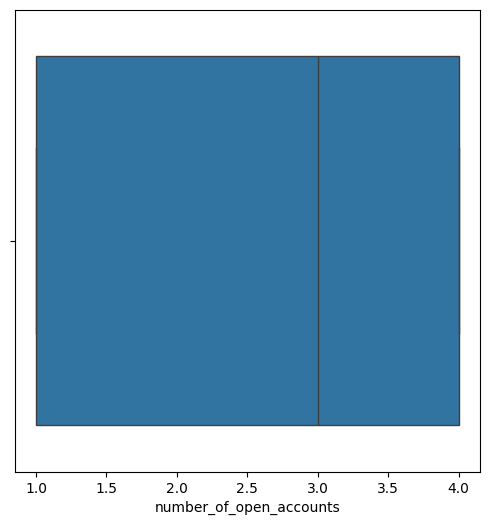

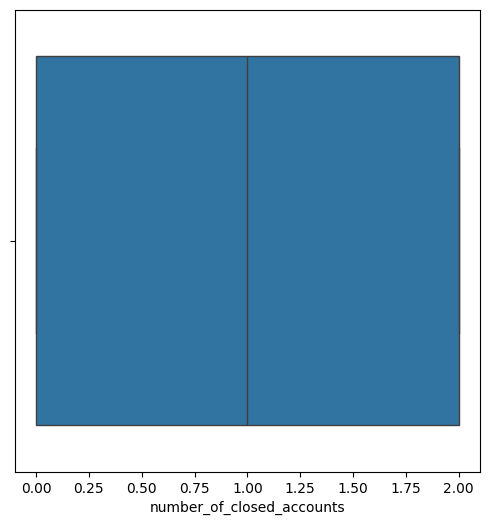

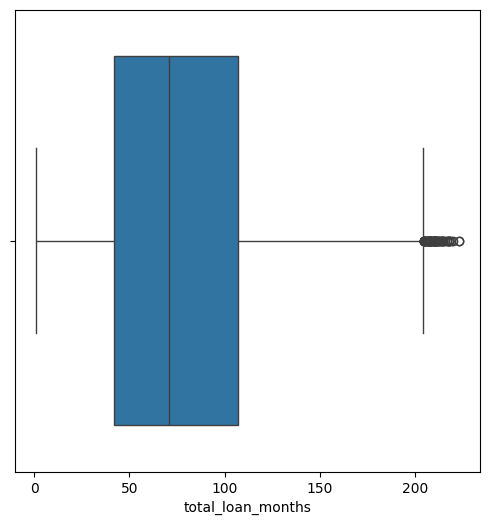

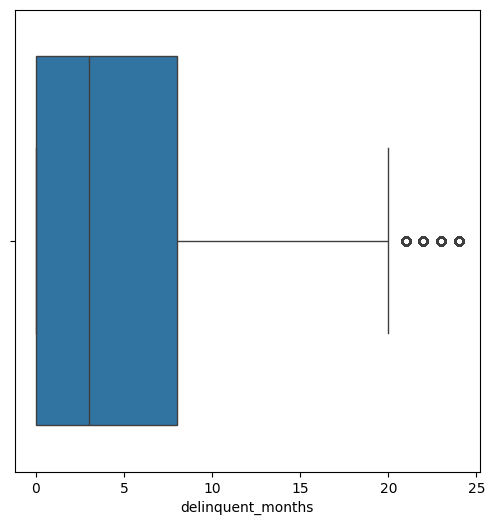

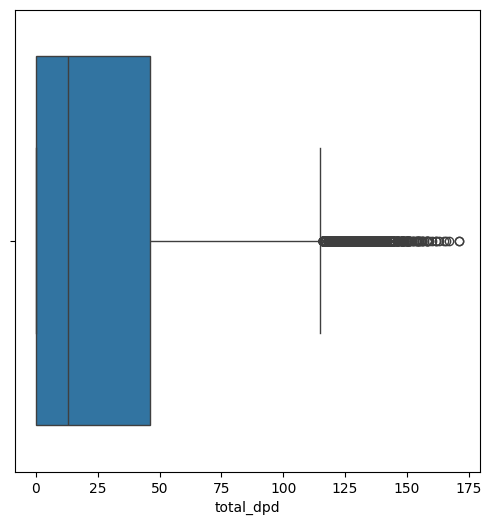

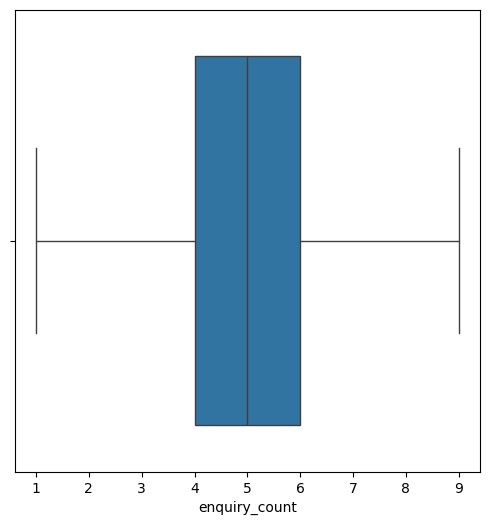

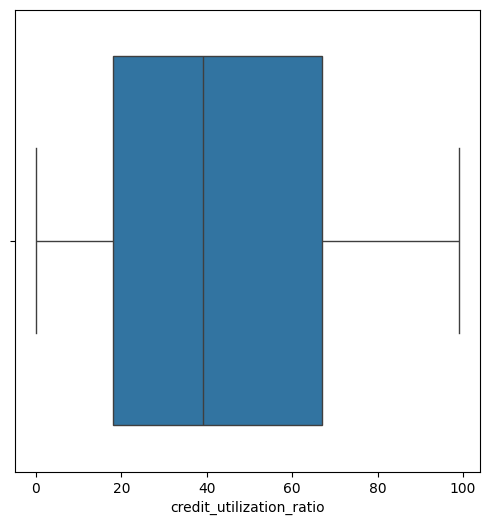

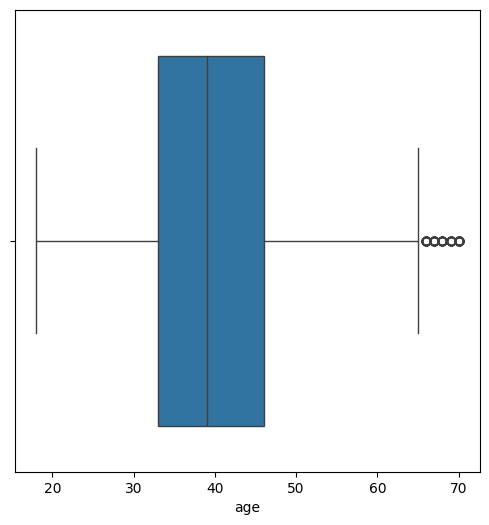

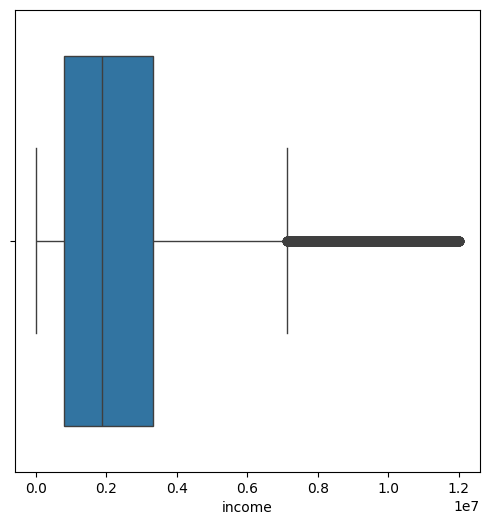

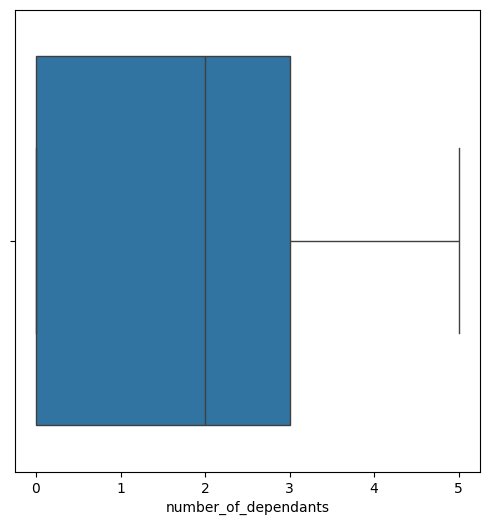

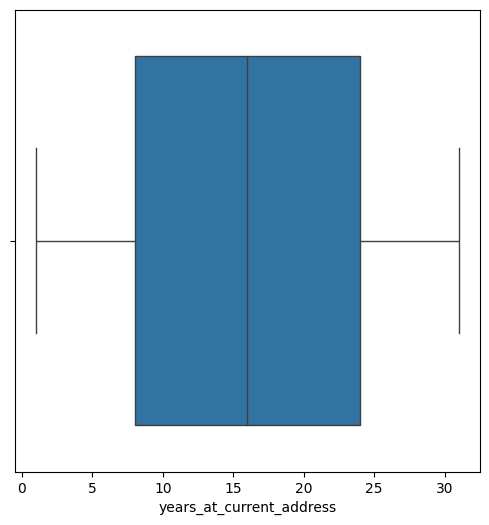

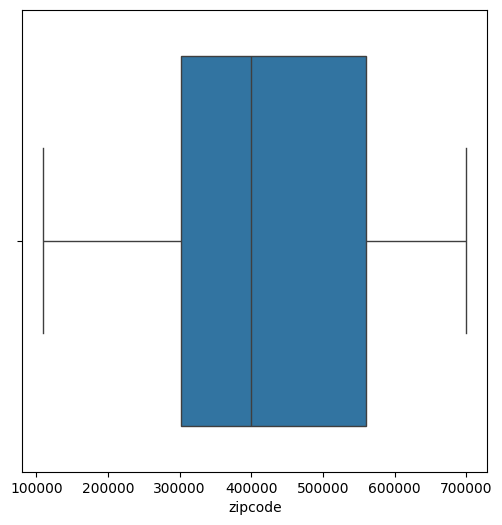

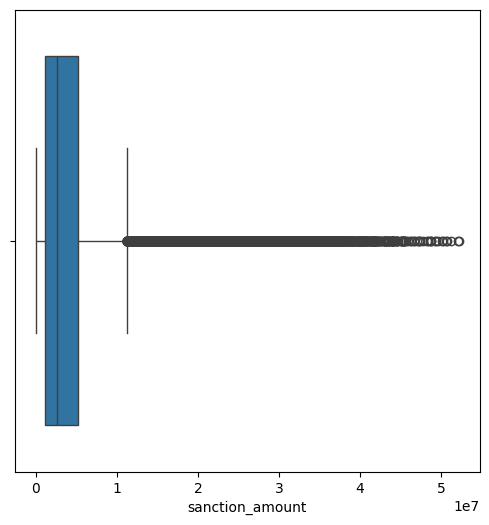

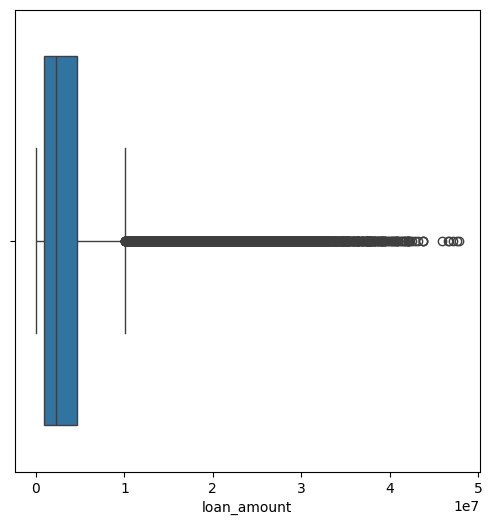

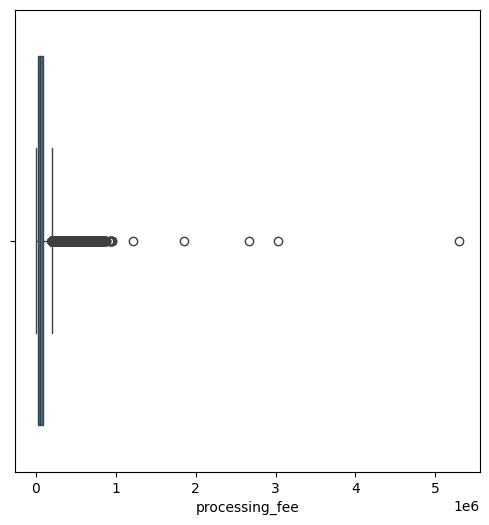

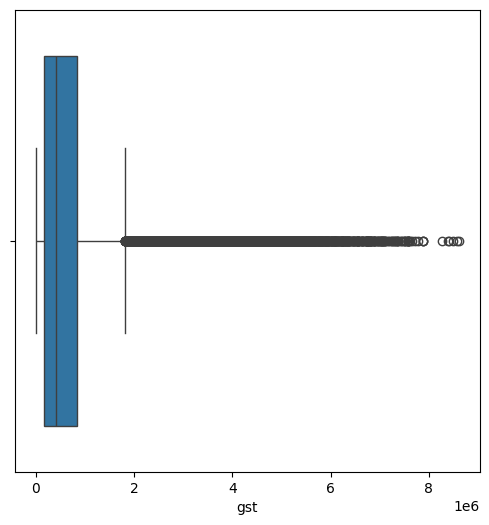

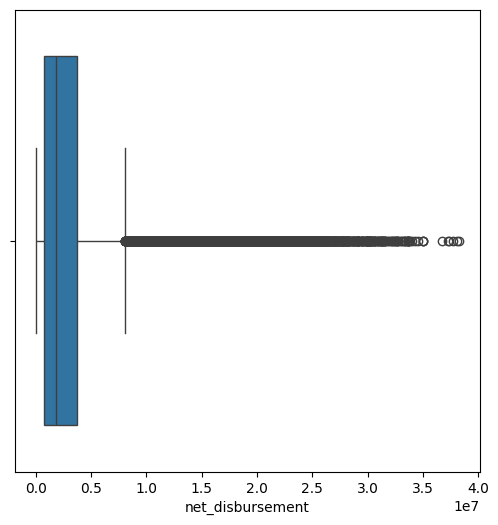

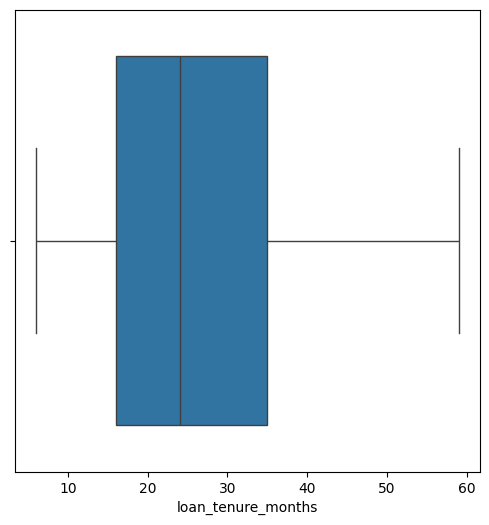

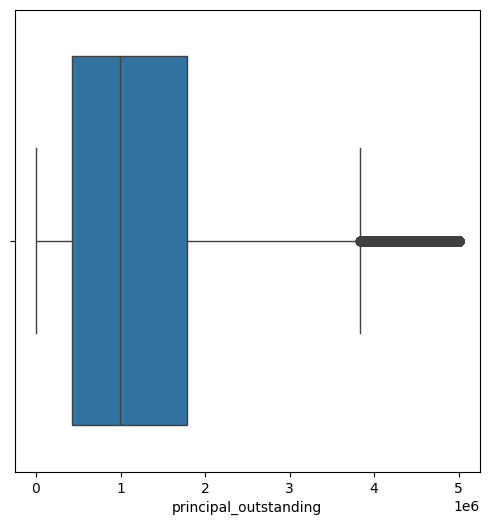

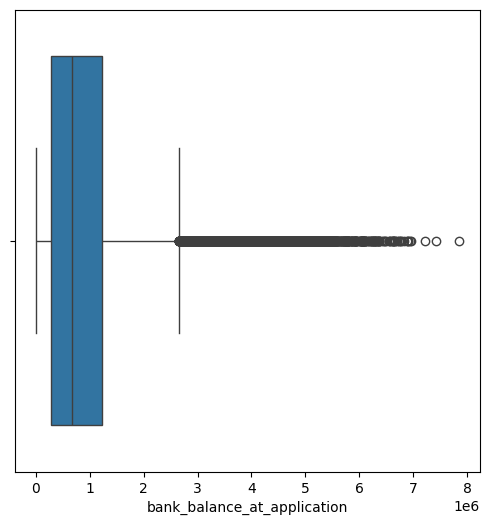

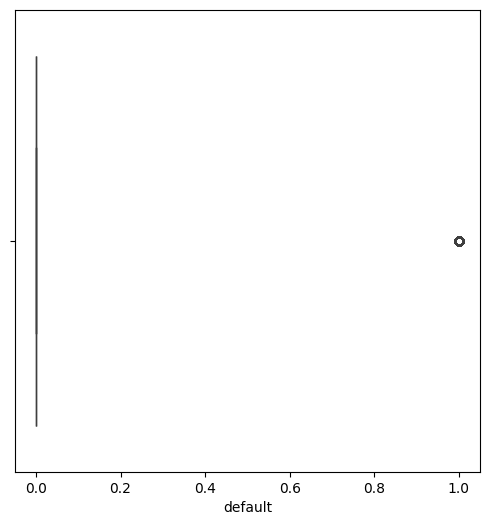

In [103]:
for cols in visualize_df:
    plt.figure(figsize=(6,6))
    sns.boxplot(x=df_train[cols])

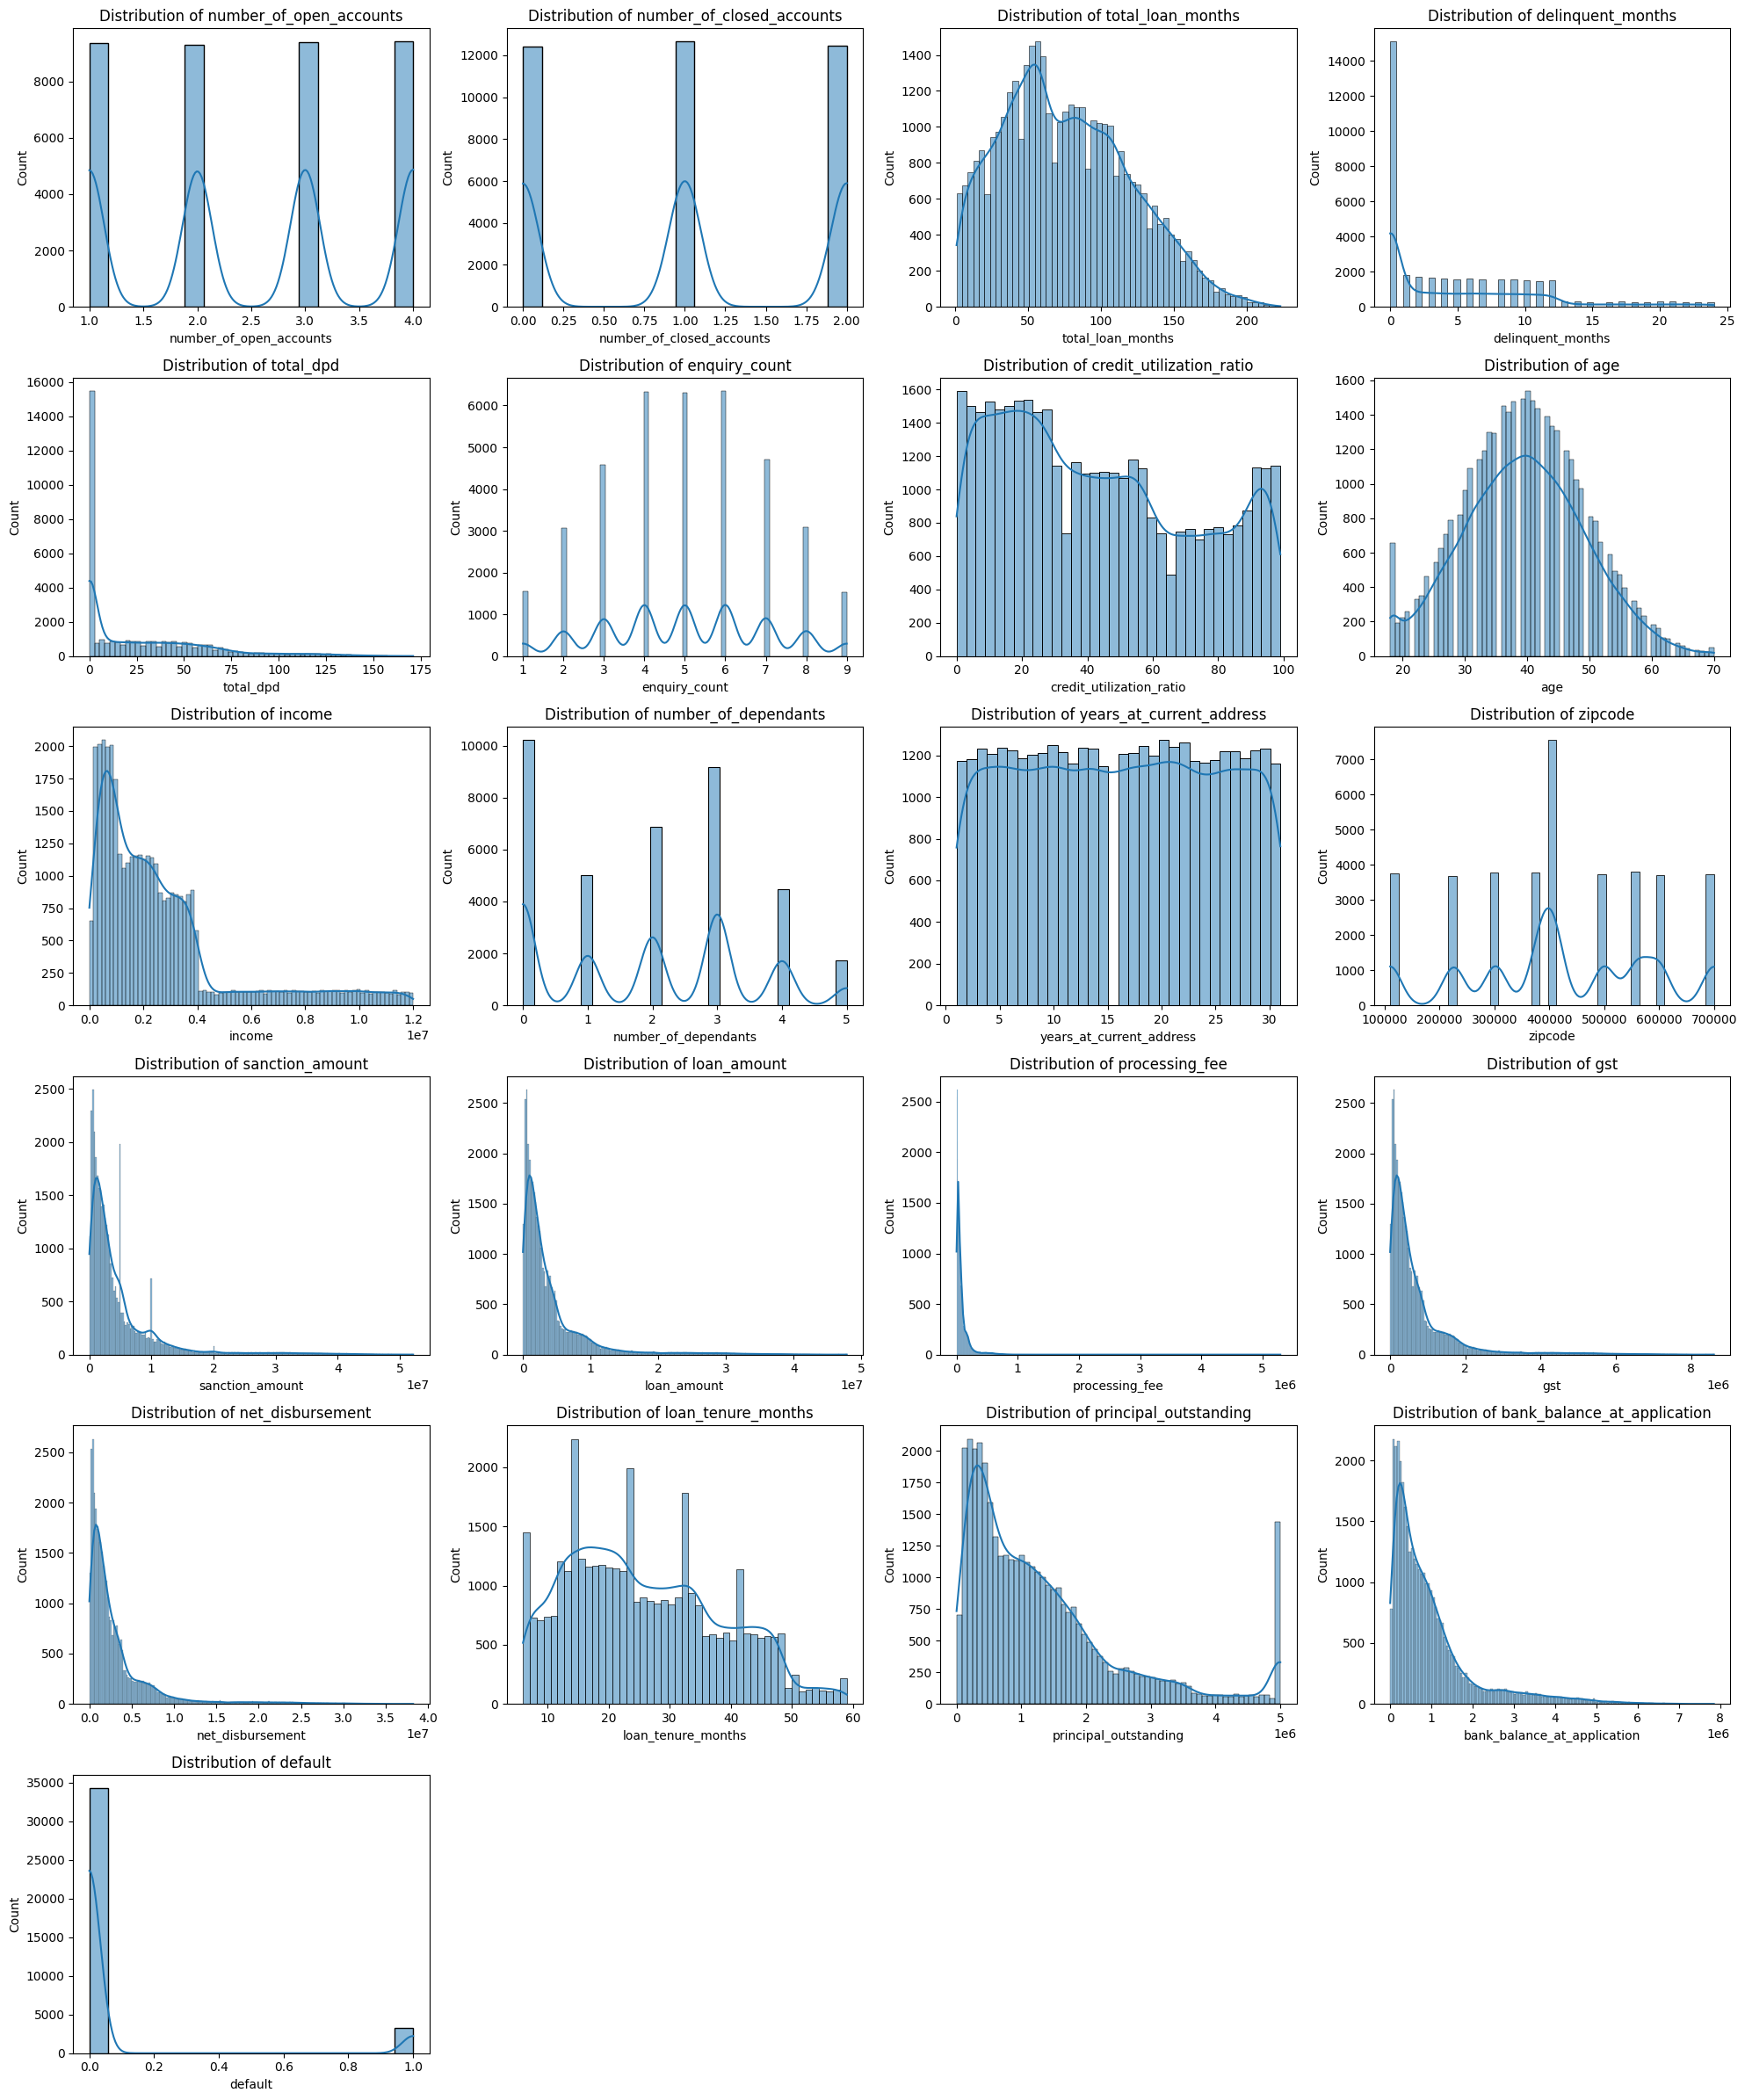

In [104]:
import math

num_cols = 4
num_plots = len(visualize_df)
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(visualize_df):
    sns.histplot(x=df_train[col], ax=axes[i], kde=True)
    axes[i].set_title(f"Distribution of {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### processing fee is heavely skewed

In [105]:
df_train.processing_fee.describe()

count     37500.00
mean      80290.68
std      113128.14
min           0.00
25%       19220.00
50%       44600.00
75%       92420.00
max     5293543.52
Name: processing_fee, dtype: float64

In [106]:
df_train[df_train.processing_fee==df_train.processing_fee.max()][['loan_amount','processing_fee']]

,loan_amount,processing_fee
9898,3626000,5293543.52


In [107]:
df_train[(df_train.processing_fee/df_train.loan_amount)>0.03][['loan_amount','processing_fee']]

,loan_amount,processing_fee
23981,2234000,2669791.02
28174,966000,1214492.67
47089,1738000,1858964.77
29305,2616000,3036378.01
9898,3626000,5293543.52


### usually processing fees is 2 to 3 percent of the loan ammount and we only get 5 record so we will ignore them

In [108]:
df_train_1=df_train[(df_train.processing_fee/df_train.loan_amount)<0.03].copy()
df_train_1=df_train_1[(df_train_1.processing_fee/df_train_1.loan_amount)<0.03]

In [109]:
df_test=df_test[(df_test.processing_fee/df_test.loan_amount)<0.03].copy()

In [110]:
df_test.shape

(12497, 33)

In [111]:
categorical_colm = df.select_dtypes(exclude=['number']).columns.tolist()

In [112]:
categorical_colm

['cust_id',
 'gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'loan_id',
 'loan_purpose',
 'loan_type',
 'disbursal_date',
 'installment_start_dt']

In [113]:
for cols in categorical_colm:
    print(cols,"-->",df_train_1[cols].unique())

cust_id --> ['C12747' 'C32496' 'C43676' ... 'C45237' 'C49229' 'C37785']
gender --> ['M' 'F']
marital_status --> ['Married' 'Single']
employment_status --> ['Self-Employed' 'Salaried']
residence_type --> ['Owned' 'Mortgage' 'Rented']
city --> ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state --> ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
loan_id --> ['L12747' 'L32496' 'L43676' ... 'L45237' 'L49229' 'L37785']
loan_purpose --> ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type --> ['Secured' 'Unsecured']
disbursal_date --> ['2020-10-31' '2022-10-22' '2023-12-04' ... '2022-02-07' '2019-10-30'
 '2022-10-04']
installment_start_dt --> ['2020-11-11' '2022-10-27' '2023-12-29' ... '2024-08-19' '2019-07-28'
 '2019-07-25']


In [114]:
df_train_1['loan_purpose']=df_train_1['loan_purpose'].replace('Personaal','Personal')
df_train_1.loan_purpose.unique()

array(['Home', 'Education', 'Personal', 'Auto'], dtype=object)

## EDA

<Axes: ylabel='age'>

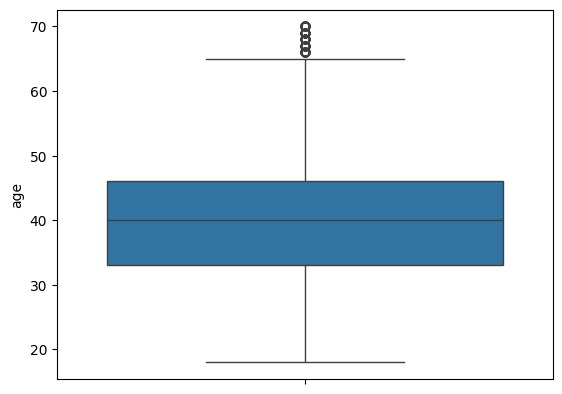

In [115]:
sns.boxplot(df.age)

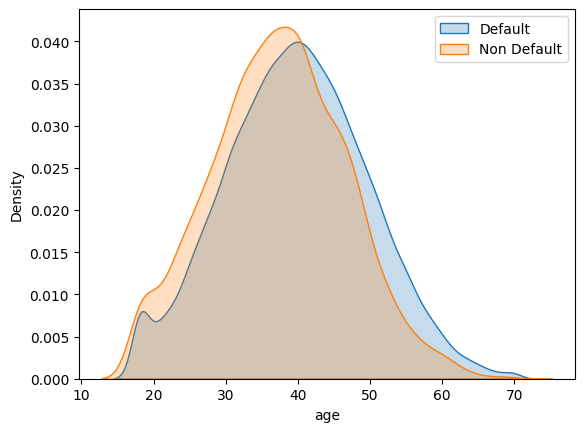

In [116]:
sns.kdeplot(df[df['default']==0]['age'],fill=True,label='Default')
sns.kdeplot(df[df['default']==1]['age'],fill=True,label='Non Default')
plt.legend()
plt.show()

### orange graph is shifted to left it represent that younger people is more defaulted

In [123]:
columns_continuous = ['age', 'income', 'number_of_dependants', 'years_at_current_address', 
                      'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 
                      'loan_tenure_months','principal_outstanding', 'bank_balance_at_application',
                      'number_of_open_accounts','number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
                       'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

columns_categorical = ['gender', 'marital_status', 'employment_status', 'residence_type', 'city', 
                       'state', 'zipcode', 'loan_purpose', 'loan_type', 'default']

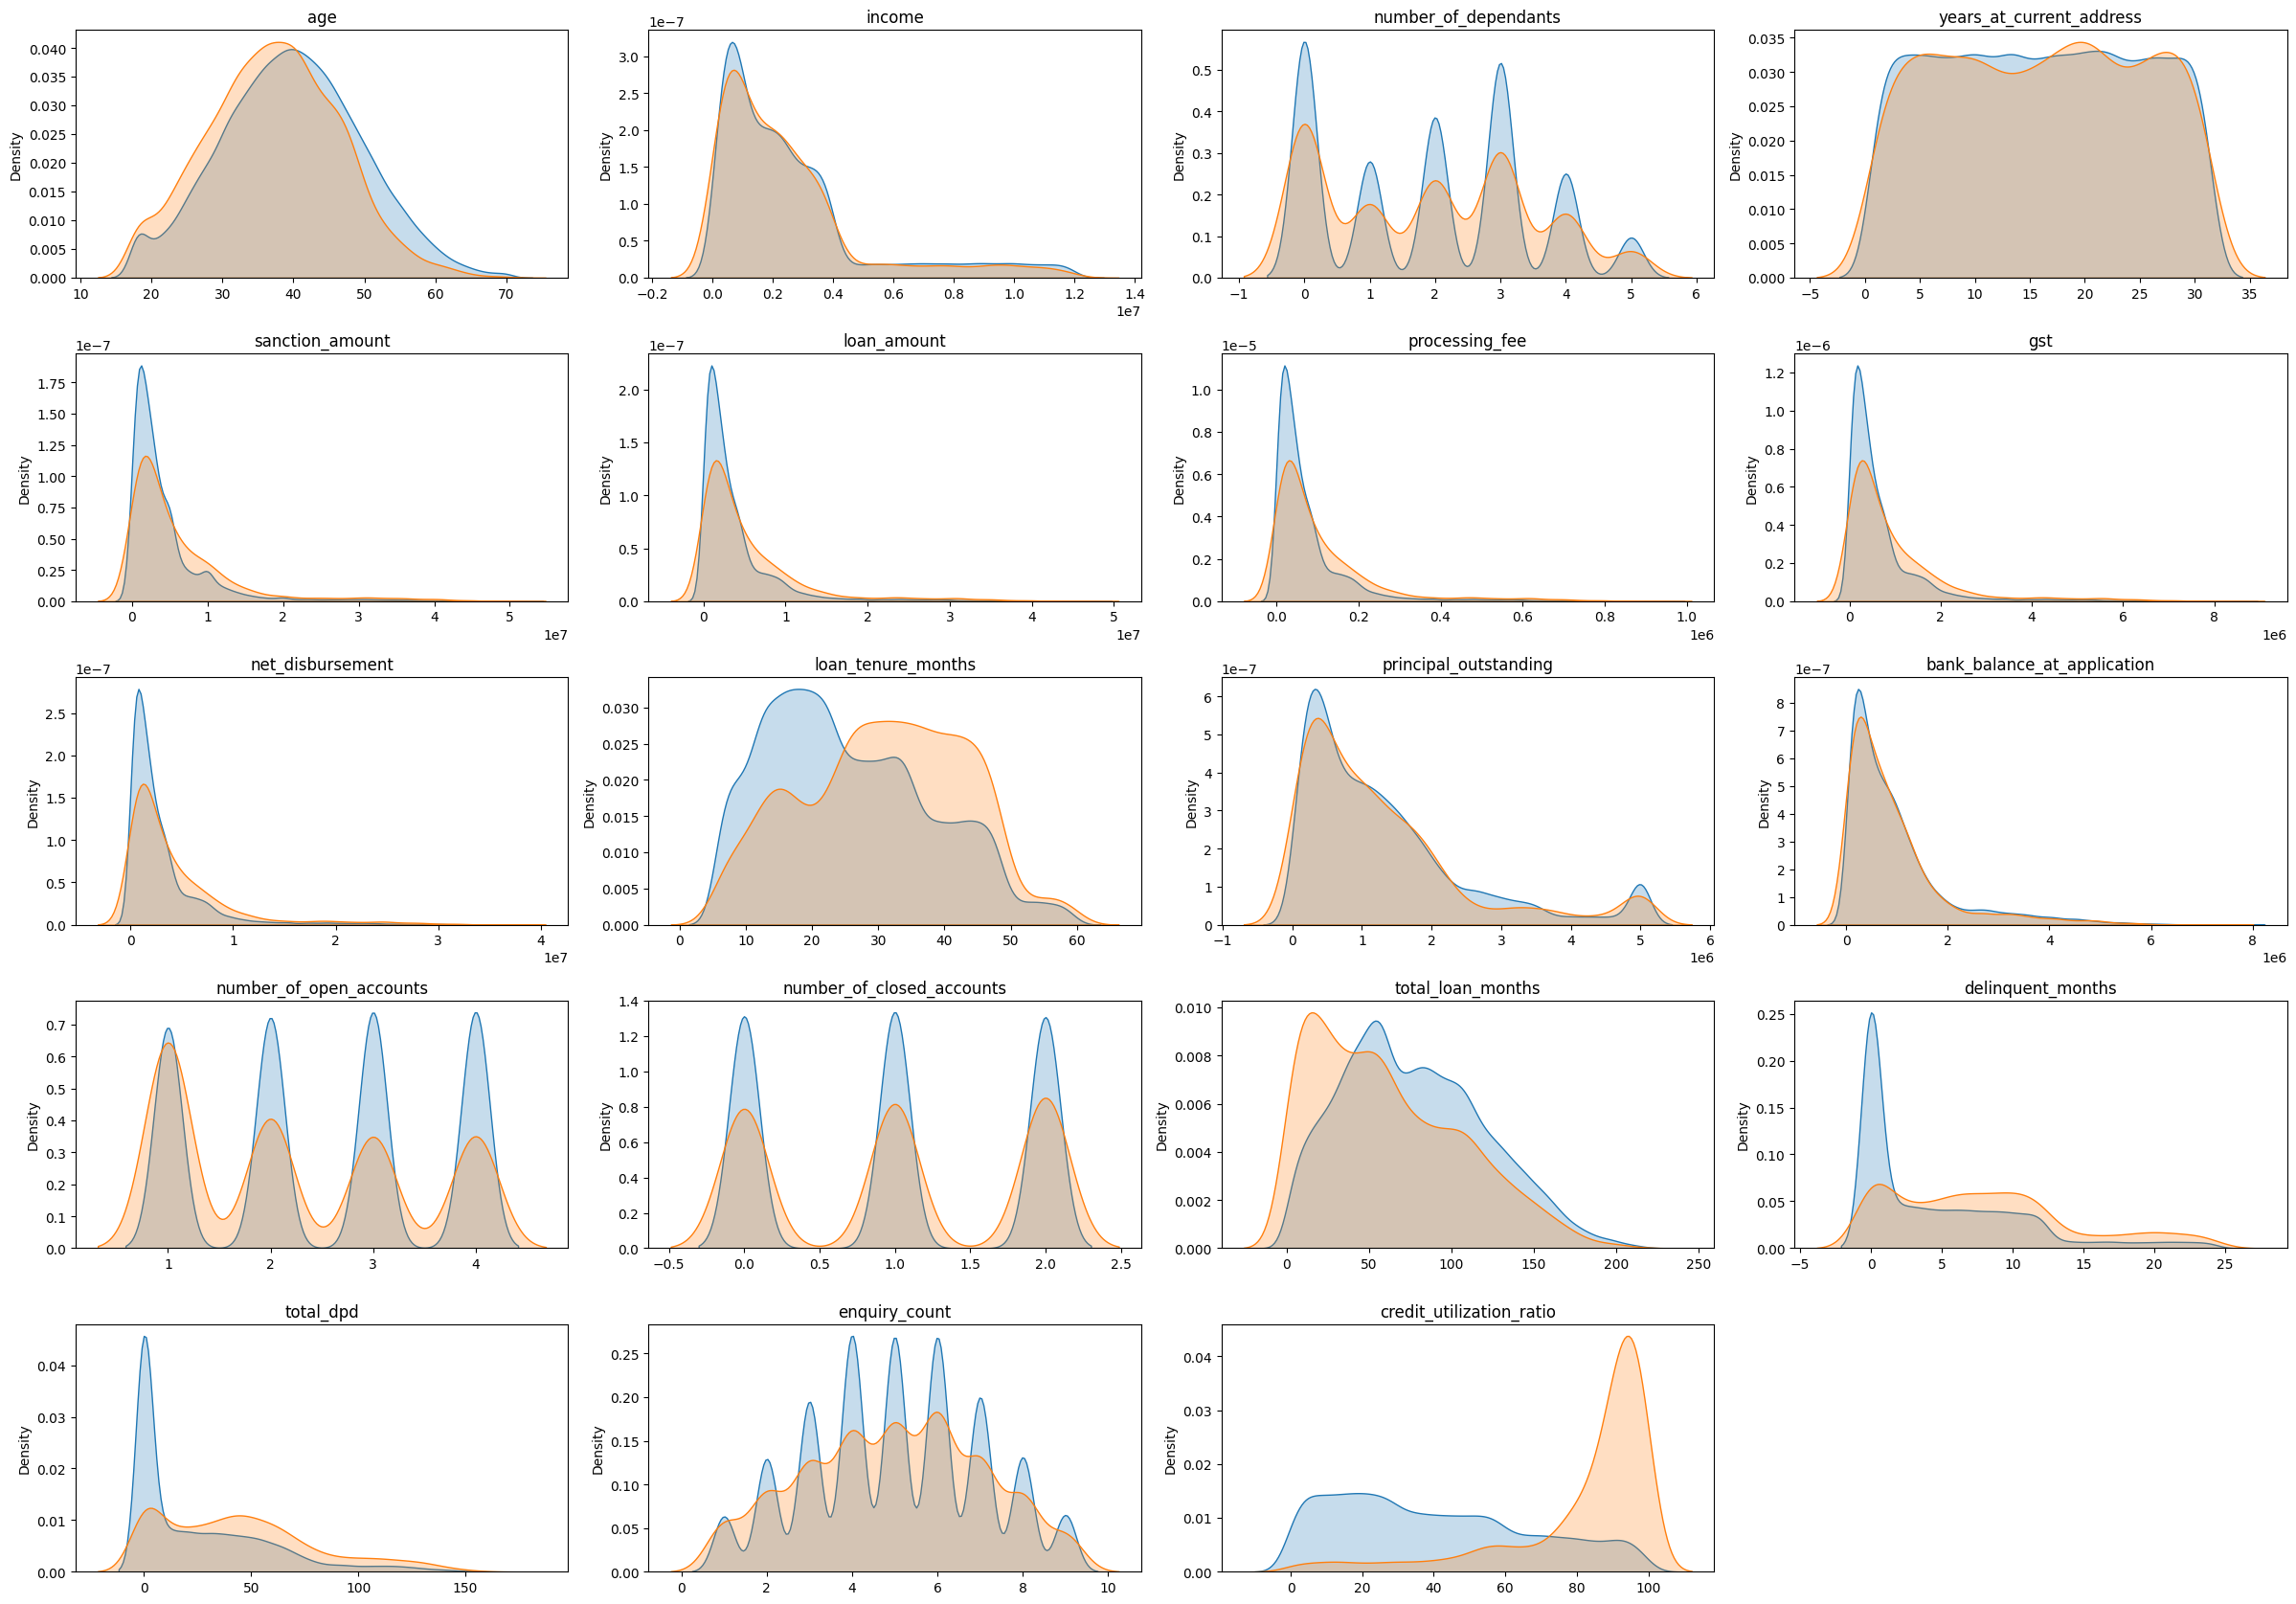

In [124]:
plt.figure(figsize=(24, 20))

for i, col in enumerate(columns_continuous):
    plt.subplot(6, 4, i+1)  # 1 row, 4 columns, ith subplot
    sns.kdeplot(df_train_1[col][df_train_1['default']==0], fill=True, label='default=0')
    sns.kdeplot(df_train_1[col][df_train_1['default']==1], fill=True, label='default=1')
    plt.title(col)        
    plt.xlabel('')
    
plt.tight_layout()
plt.show()